# Environment Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
#import seaborn as sns # Optional, but good for color palettes

# Plotting style configuration for academic look
#plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16
})

# Data Loading & Preprocessing

## Stage A: Static Competitive Market (SugarScape Model 2)

In [6]:
experiment_A = pd.read_csv("../Experiment-sheet/Stage-A.csv")
vals_A = ["initial-population","step","market-utilization","gini-index","mean-vision","mean-metabolism"]
experiment_A = experiment_A[vals_A]
experiment_A_summary = experiment_A.groupby(['initial-population', 'step']).agg(['mean', 'std'])
experiment_A_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_A_summary.columns.values]
experiment_A_summary = experiment_A_summary.reset_index()
experiment_A_500Tick = experiment_A_summary[experiment_A_summary["step"] == 500]
experiment_A_summary

,initial-population,step,market-utilization_mean,market-utilization_std,gini-index_mean,gini-index_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
0,10,0,1.222813,0.218430,0.210932,0.045714,3.433333,0.472217,2.530000,0.451931
1,10,1,1.222813,0.218430,0.220176,0.046909,3.433333,0.472217,2.530000,0.451931
2,10,2,1.205091,0.213877,0.232550,0.056072,3.452963,0.495864,2.520741,0.451776
3,10,3,1.176092,0.217017,0.247049,0.055955,3.457778,0.501979,2.502222,0.457001
4,10,4,1.126148,0.203143,0.254912,0.070604,3.490741,0.538181,2.477500,0.455018
...,...,...,...,...,...,...,...,...,...,...
8011,2499,496,45.859513,0.805773,0.328421,0.016792,3.854924,0.040700,1.239354,0.018327
8012,2499,497,45.859513,0.805773,0.328428,0.016794,3.854924,0.040700,1.239354,0.018327
8013,2499,498,45.859513,0.805773,0.328432,0.016793,3.854924,0.040700,1.239354,0.018327
8014,2499,499,45.859513,0.805773,0.328434,0.016797,3.854924,0.040700,1.239354,0.018327


In [7]:
experiment_A_500Tick

,initial-population,step,market-utilization_mean,market-utilization_std,gini-index_mean,gini-index_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
500,10,500,0.766876,0.239396,0.340890,0.147338,3.820529,0.633049,2.281574,0.563311
1001,50,500,3.710327,0.357360,0.361837,0.054273,3.930374,0.283153,2.187472,0.162771
1502,100,500,5.925568,0.353488,0.320532,0.035879,3.698508,0.255073,1.943568,0.089955
2003,200,500,11.248590,0.678193,0.358855,0.023844,3.714830,0.131584,1.898870,0.079538
2504,300,500,16.288062,0.892292,0.378938,0.022877,3.781653,0.120712,1.858166,0.054176
3005,400,500,20.141775,0.710559,0.388198,0.021235,3.832227,0.125956,1.823105,0.052108
3506,600,500,21.696472,0.610882,0.321609,0.018865,3.747069,0.091233,1.576993,0.041673
4007,800,500,24.681811,1.065913,0.315424,0.012704,3.605052,0.090119,1.464889,0.022448
4508,1000,500,30.947318,1.353855,0.367451,0.015404,3.631699,0.081196,1.459210,0.027470
5009,1200,500,36.972773,1.345280,0.403157,0.012144,3.647035,0.076373,1.458462,0.018728


## Stage B: Dynamic Competitive Market (SugarScape Model 3)

### Stage B — Primary Experimen

In [8]:
experiment_B_1 = pd.read_csv("../Experiment-sheet/Stage-B-1.csv")
cols_B_1 = ["maximum-sugar-endowment", "minimum-sugar-endowment", "step", "gini-index", "brand-gini-index", "market-utilization", "mean-vision", "mean-metabolism"]
experiment_B_1 = experiment_B_1[cols_B_1]
experiment_B_summary_1 = experiment_B_1.groupby(['maximum-sugar-endowment', "minimum-sugar-endowment", 'step']).agg(['mean', 'std'])
experiment_B_summary_1.columns = [f"{col[0]}_{col[1]}" for col in experiment_B_summary_1.columns.values]


experiment_B_summary_1 = experiment_B_summary_1.reset_index()

experiment_B_1_1000Tick = experiment_B_summary_1[experiment_B_summary_1["step"] == 1000]

experiment_B_summary_1

,maximum-sugar-endowment,minimum-sugar-endowment,step,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
0,1,0,0,0.510333,0.032553,0.510333,0.032553,48.516191,0.984134,3.499833,0.071467,2.509500,0.050904
1,1,0,1,0.317898,0.012011,0.257014,0.005020,19.655228,0.997851,3.625510,0.083811,1.942601,0.057989
2,1,0,2,0.406218,0.011818,0.344033,0.009343,24.185597,0.997873,3.625421,0.079418,1.984823,0.063143
3,1,0,3,0.454539,0.014413,0.384672,0.009004,28.461415,1.491485,3.600584,0.091564,1.968732,0.055237
4,1,0,4,0.477537,0.011079,0.403778,0.011747,32.585790,1.490515,3.603080,0.088938,1.934160,0.070110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36031,50,49,996,0.330810,0.007556,0.529722,0.023073,75.488964,1.024452,3.517255,0.043592,1.042810,0.008355
36032,50,49,997,0.331169,0.007573,0.529725,0.023097,75.601740,0.959756,3.516352,0.044045,1.043536,0.008021
36033,50,49,998,0.331154,0.007251,0.529710,0.023084,75.601740,0.887305,3.516863,0.043974,1.043499,0.008174
36034,50,49,999,0.331518,0.007139,0.529711,0.023099,75.746738,0.747247,3.517444,0.043870,1.044581,0.007618


### Stage B — Secondary Experimen

In [9]:
experiment_B_efficiency_gain = pd.read_csv("../Experiment-sheet/Stage-B-2.csv")
                                           
experiment_B_efficiency_gain
experiment_B_efficiency_gain_summary = experiment_B_efficiency_gain.groupby(['efficiency-gain', 'step']).agg(['mean', 'std'])


experiment_B_efficiency_gain_summary.columns = [f"{col[0]}_{col[1]}" for col in experiment_B_efficiency_gain_summary.columns.values]


experiment_B_efficiency_gain_summary = experiment_B_efficiency_gain_summary.reset_index()
cols_B_2 = ["efficiency-gain","step","gini-index_mean",
    "gini-index_std","brand-gini-index_mean","brand-gini-index_std","market-utilization_mean","market-utilization_std",
    "mean-vision_mean","mean-vision_std","mean-metabolism_mean","mean-metabolism_std"]
experiment_B_efficiency_gain_summary = experiment_B_efficiency_gain_summary[cols_B_2]

experiment_B_efficiency_gain_1000tick = experiment_B_efficiency_gain_summary[experiment_B_efficiency_gain_summary["step"] == 1000]


experiment_B_efficiency_gain_1000tick

,efficiency-gain,step,gini-index_mean,gini-index_std,brand-gini-index_mean,brand-gini-index_std,market-utilization_mean,market-utilization_std,mean-vision_mean,mean-vision_std,mean-metabolism_mean,mean-metabolism_std
1000,0.0,1000,0.204512,0.003854,0.511960,0.033109,75.804737,0.264911,3.512887,0.043307,1.000021,0.000117
2001,0.1,1000,0.438369,0.010461,0.637671,0.034959,77.526986,0.651607,3.494073,0.047009,1.001513,0.001706
3002,0.2,1000,0.565648,0.004545,0.698706,0.030431,81.372644,1.328840,3.495282,0.033938,1.006435,0.002880
4003,0.3,1000,0.610400,0.009090,0.752337,0.028212,90.288384,2.853749,3.502254,0.033903,1.015635,0.004187
5004,0.4,1000,0.606022,0.015584,0.781876,0.026353,97.375544,3.094249,3.509333,0.037651,1.018346,0.004501
6005,0.5,1000,0.562958,0.019961,0.821811,0.021062,101.010150,1.540710,3.500922,0.043139,1.012271,0.004636
7006,0.6,1000,0.512578,0.027289,0.824161,0.022506,101.449976,1.445023,3.504100,0.026782,1.010309,0.003298
8007,0.7,1000,0.465796,0.024788,0.833788,0.024995,102.207185,0.588858,3.492682,0.040174,1.011590,0.003202
9008,0.8,1000,0.428233,0.021587,0.839498,0.019401,102.700177,0.484114,3.509744,0.038552,1.014366,0.003610
10009,0.9,1000,0.431307,0.023192,0.829556,0.027529,104.440148,0.535467,3.510013,0.035825,1.030701,0.004548


# Data Visualization

## Stage A: Static Competitive Market (SugarScape Model 2)

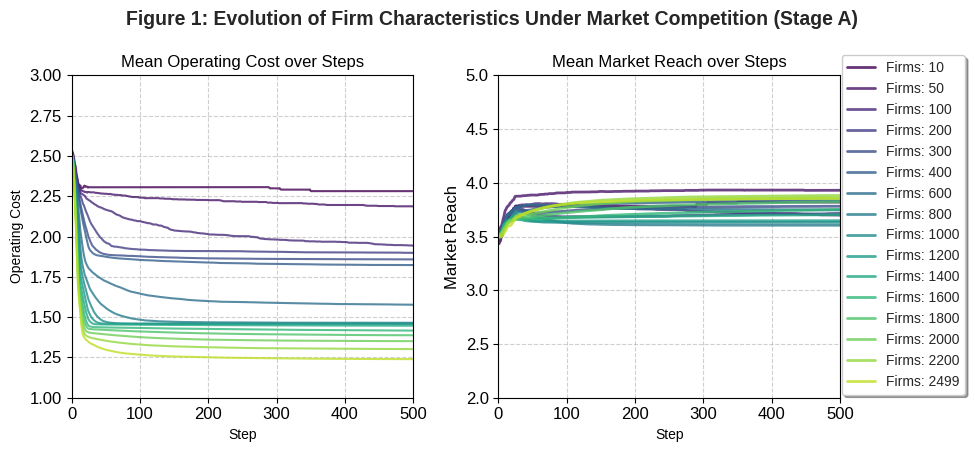

In [10]:
# 1. Setup the figure with two subplots side-by-side
# Using sharex=True as both use 'Step' as the horizontal axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Identify unique initial populations
# Standardizing column names to English 'initial-population'
unique_pops = sorted(experiment_A_summary['initial-population'].unique())

# 3. Define color maps for differentiation

colors = plt.cm.viridis(np.linspace(0, 0.9, len(unique_pops)))

# 4. Loop through each population group
for i, pop_size in enumerate(unique_pops):
    # Filtering data for the current population group
    subset = experiment_A_summary[experiment_A_summary['initial-population'] == pop_size].sort_values('step')
    
    if subset.empty:
        continue

    x = subset['step'].values
    y_meta = subset['mean-metabolism_mean'].values
    y_vision = subset['mean-vision_mean'].values
    
    # Generate smooth curves if enough points exist (cubic spline needs > 3 points)
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        
        # Smooth Metabolism data
        spl_meta = make_interp_spline(x, y_meta, k=3)
        y_meta_smooth = spl_meta(x_smooth)
        
        # Smooth Vision data
        spl_vision = make_interp_spline(x, y_vision, k=3)
        y_vision_smooth = spl_vision(x_smooth)
        
        # Plot Metabolism (Left Subplot)
        ax1.plot(x_smooth, y_meta_smooth, color=colors[i], linewidth=1.5, alpha=0.8)
        
        # Plot Vision (Right Subplot)
        # Label is added here to be captured for the shared legend
        ax2.plot(x_smooth, y_vision_smooth, label=f'Pop: {pop_size}', color=colors[i], linewidth=2, alpha=0.8)
    else:
        # Fallback for sparse data points
        ax1.plot(x, y_meta, color=colors_metabolism[i], linewidth=1.5)
        ax2.plot(x, y_vision, label=f'Pop: {pop_size}', color=colors[i], linewidth=2)

# 5. Formatting Metabolism Subplot (Left)
ax1.set_title('Mean Operating Cost over Steps', fontsize=12)
ax1.set_xlabel('Step', fontsize=10)
ax1.set_ylabel('Operating Cost', fontsize=10)
ax1.set_ylim(1, 3)
ax1.grid(True, linestyle='--', alpha=0.6)

# 6. Formatting Vision Subplot (Right)
ax2.set_title('Mean Market Reach over Steps', fontsize=12)
ax2.set_xlabel('Step', fontsize=10)
ax2.set_ylabel('Market Reach', fontsize=12)
ax2.set_ylim(2, 5)
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--', alpha=0.6)

# 7. Legend
handles, labels = ax2.get_legend_handles_labels()
# Change 'Pop: X' to 'Firms: X' in legend labels
labels = [l.replace('Pop:', 'Firms:') for l in labels]
fig.legend(handles, labels, loc='center right', 
           bbox_to_anchor=(0.98, 0.5), fontsize='small', frameon=True, shadow=True)

# 8. Main title
fig.suptitle('Figure 1: Evolution of Firm Characteristics Under Market Competition (Stage A)', 
             fontsize=14,fontweight='bold',  y=0.93)

plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
plt.savefig('./figure/stage_A_1', dpi=300, bbox_inches='tight')
plt.show()

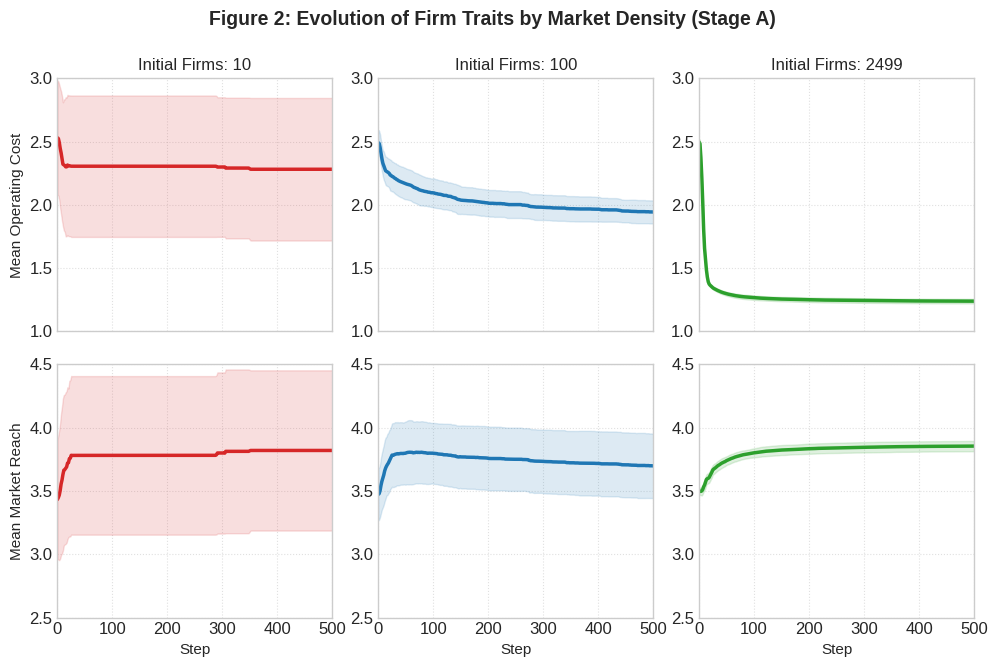

In [11]:
# 1. Setup figure with 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(10, 7), sharex=True)

target_pops = [10, 100, 2499] 
# Applying a logical color gradient: Blue (Low) -> Cyan (Medium) -> Red (High Density)
line_colors = ['#d62728', '#1f77b4', '#2ca02c'] 

# 2. Loop through populations
for i, pop_size in enumerate(target_pops):
    subset = experiment_A_summary[experiment_A_summary['initial-population'] == pop_size].sort_values('step')
    
    if subset.empty: 
        continue
        
    x = subset['step'].values
    y_vision_mean = subset['mean-vision_mean'].values
    y_vision_std = subset['mean-vision_std'].values
    y_meta_mean = subset['mean-metabolism_mean'].values
    y_meta_std = subset['mean-metabolism_std'].values
    
    # Apply B-Spline smoothing
    x_smooth = np.linspace(x.min(), x.max(), 300)
    
    y_vision_mean_smooth = make_interp_spline(x, y_vision_mean, k=3)(x_smooth)
    y_vision_std_smooth = make_interp_spline(x, y_vision_std, k=3)(x_smooth)

    y_meta_mean_smooth = make_interp_spline(x, y_meta_mean, k=3)(x_smooth)
    y_meta_std_smooth = make_interp_spline(x, y_meta_std, k=3)(x_smooth)

    # --- TOP row: Operating Cost (metabolism) - MOVED HERE ---
    ax_top = axes[0, i]
    ax_top.plot(x_smooth, y_meta_mean_smooth, 
                color=line_colors[i], linewidth=2.5)
    ax_top.fill_between(x_smooth, 
                         y_meta_mean_smooth - y_meta_std_smooth, 
                         y_meta_mean_smooth + y_meta_std_smooth, 
                         color=line_colors[i], alpha=0.15)
    ax_top.set_title(f'Initial Firms: {pop_size}', fontsize=12)
    ax_top.set_ylim(1.0, 3.0) # Adjusted for Metabolism
    ax_top.grid(True, linestyle=':', alpha=0.6)

    # --- BOTTOM row: Market Reach (vision) - MOVED HERE ---
    ax_bot = axes[1, i]
    ax_bot.plot(x_smooth, y_vision_mean_smooth, 
                color=line_colors[i], linewidth=2.5)
    ax_bot.fill_between(x_smooth, 
                         y_vision_mean_smooth - y_vision_std_smooth, 
                         y_vision_mean_smooth + y_vision_std_smooth, 
                         color=line_colors[i], alpha=0.15)
    ax_bot.set_ylim(2.5, 4.5) # Adjusted for Vision
    ax_bot.set_xlim(0, 500)
    ax_bot.grid(True, linestyle=':', alpha=0.6)

# 3. Updated Y-axis labels for the new positions
axes[0, 0].set_ylabel('Mean Operating Cost', fontsize=11)
axes[1, 0].set_ylabel('Mean Market Reach', fontsize=11)

# 4. Shared X-axis labels (bottom row only)
for ax in axes[1]:
    ax.set_xlabel('Step', fontsize=11)

# 5. Main title
fig.suptitle('Figure 2: Evolution of Firm Traits by Market Density (Stage A)', 
             fontsize=14, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# Save FIRST, show SECOND
plt.savefig('./figure/stage_A_2.png', dpi=300, bbox_inches='tight')
plt.show()

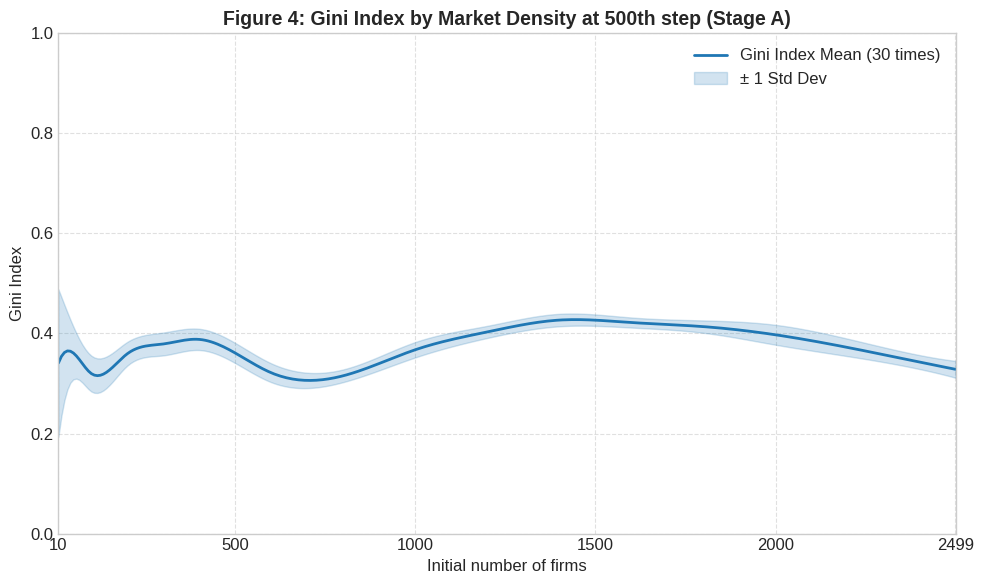

In [12]:
# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_A_500Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['gini-index_mean'].values
y_std = df_sorted['gini-index_std'].values

# Create 300 points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (no markers)
plt.plot(x_smooth, y_mean_smooth, 
         label='Gini Index Mean (30 times)', color='#1f77b4', linewidth=2)

# 4. Plot the smoothed shaded area (Mean ± Std)
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color='#1f77b4', alpha=0.2, label='± 1 Std Dev')

# 5. Chart formatting
plt.title('Figure 4: Gini Index by Market Density at 500th step (Stage A)',fontweight='bold',fontsize=14)
plt.xlabel('Initial number of firms', fontsize=12)
plt.ylabel('Gini Index', fontsize=12)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# --- KEY MODIFICATIONS START ---

# Set the limits of the X-axis (start and end only)
plt.xlim(10, 2500)

# Manually define the exact ticks you want to see
custom_ticks_x = [10, 500, 1000, 1500, 2000, 2499]
plt.xticks(custom_ticks_x)

custom_ticks_y = [0.0, 0.2, 0.4, 0.6, 0.8, 1]
plt.yticks(custom_ticks_y)


# --- KEY MODIFICATIONS END ---

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend()

# 6. Display the plot
plt.tight_layout()
plt.savefig('./figure/stage_A_4', dpi=300, bbox_inches='tight')
plt.show()

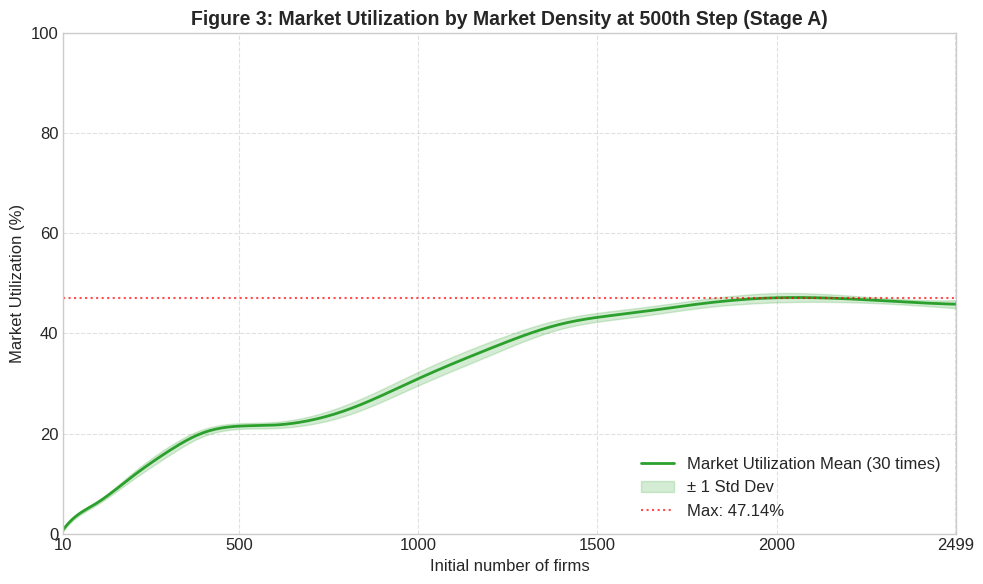

In [13]:
# 1. Setup the figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Prepare data for smoothing
df_sorted = experiment_A_500Tick.sort_values('initial-population')
x = df_sorted['initial-population'].values
y_mean = df_sorted['market-utilization_mean'].values
y_std = df_sorted['market-utilization_std'].values

# Find the maximum point for the auxiliary lines
max_idx = np.argmax(y_mean)
x_max = x[max_idx]
y_max = y_mean[max_idx]

# Create points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300) 

# Interpolate Mean and Std values
spl_mean = make_interp_spline(x, y_mean, k=3)
y_mean_smooth = spl_mean(x_smooth)

spl_std = make_interp_spline(x, y_std, k=3)
y_std_smooth = spl_std(x_smooth)

# 3. Plot the smoothed mean line (Changed to Green)
main_color = '#2ca02c' 
plt.plot(x_smooth, y_mean_smooth, 
         label='Market Utilization Mean (30 times)', color=main_color, linewidth=2)

# 4. Plot the smoothed shaded area
plt.fill_between(x_smooth, 
                 y_mean_smooth - y_std_smooth, 
                 y_mean_smooth + y_std_smooth, 
                 color=main_color, alpha=0.2, label='± 1 Std Dev')

# --- AUXILIARY LINES FOR MAX POINT ---
# Horizontal line at max Y
plt.axhline(y=y_max, color='red', linestyle=':', alpha=0.7, label=f'Max: {y_max:.2f}%')
# Vertical line at corresponding X
#plt.axvline(x=x_max, color='gray', linestyle='--', alpha=0.5)

# 5. Chart formatting
plt.title('Figure 3: Market Utilization by Market Density at 500th Step (Stage A)',fontweight='bold',fontsize=14)
plt.xlabel('Initial number of firms', fontsize=12)
plt.ylabel('Market Utilization (%)', fontsize=12)

# Coordinate settings
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100])
plt.xlim(10, 2500)
plt.xticks([10, 500, 1000, 1500, 2000, 2499])

# Customize the grid appearance
plt.grid(visible=True, which='major', linestyle='--', alpha=0.6)

plt.legend(loc='lower right')

# 6. Display the plot
plt.tight_layout()
plt.savefig('./figure/stage_A_3', dpi=300, bbox_inches='tight')
plt.show()

## Stage B: Dynamic Competitive Market (SugarScape Model 3)

### Stage B — Primary Experimen

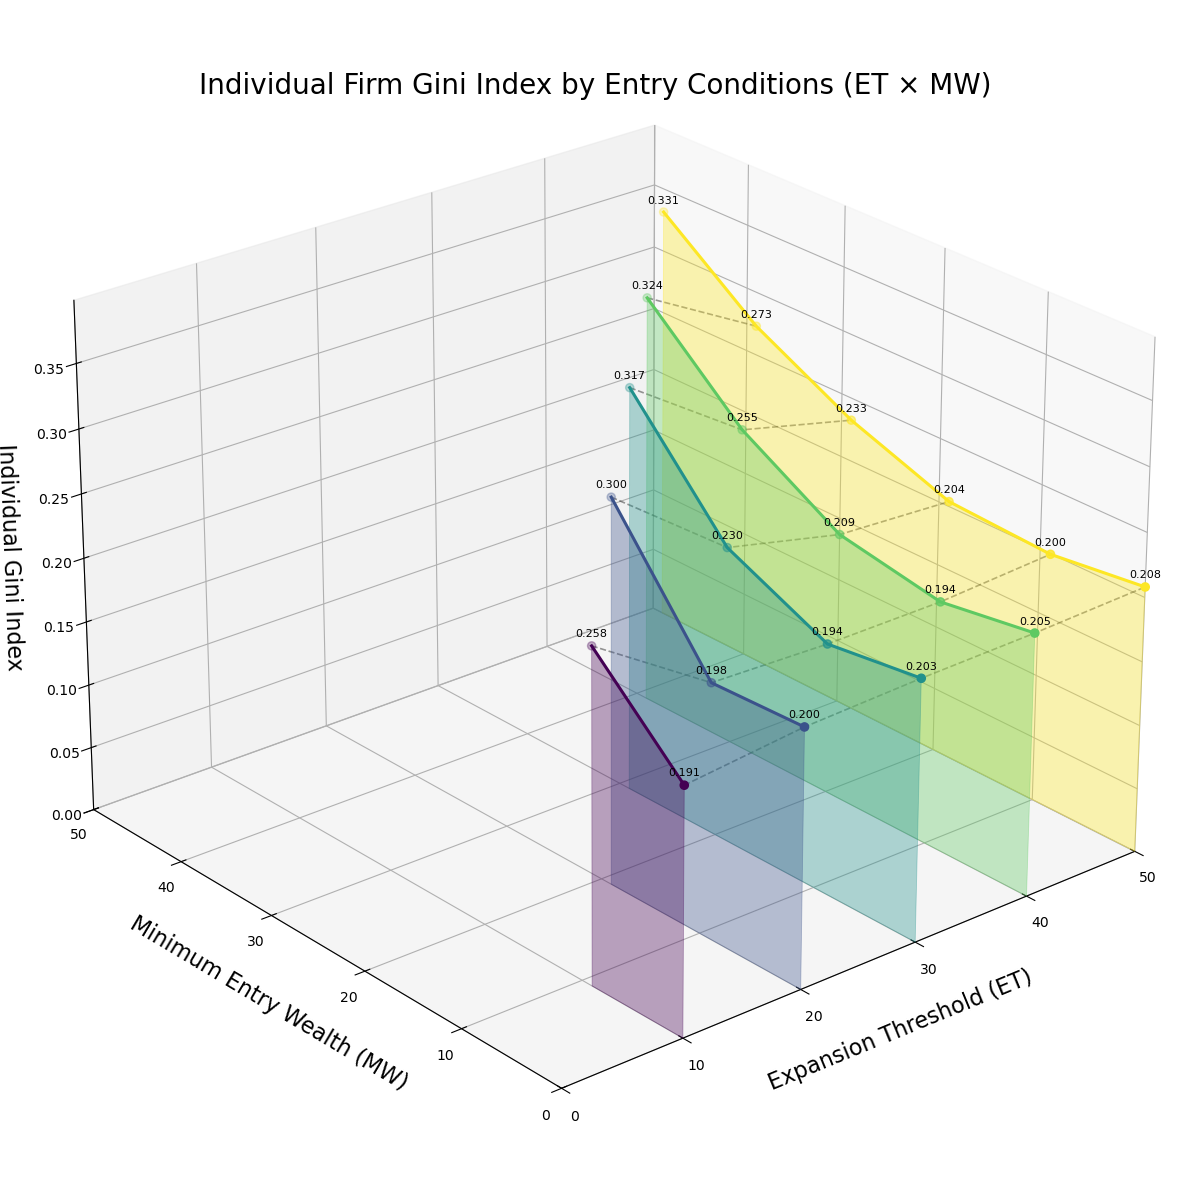

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(16, 12)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["gini-index_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=8, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["gini-index_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Expansion Threshold (ET)', labelpad=15,fontsize=16)
ax.set_ylabel('Minimum Entry Wealth (MW)', labelpad=15,fontsize=16)
ax.set_zlabel('Individual Gini Index', labelpad=10, fontsize=16)
ax.set_title('Individual Firm Gini Index by Entry Conditions (ET × MW)', pad=30, fontsize=20, y=0.97)

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["gini-index_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
#plt.savefig('./figure/stage_B_1_1', dpi=300, bbox_inches='tight')
plt.show()

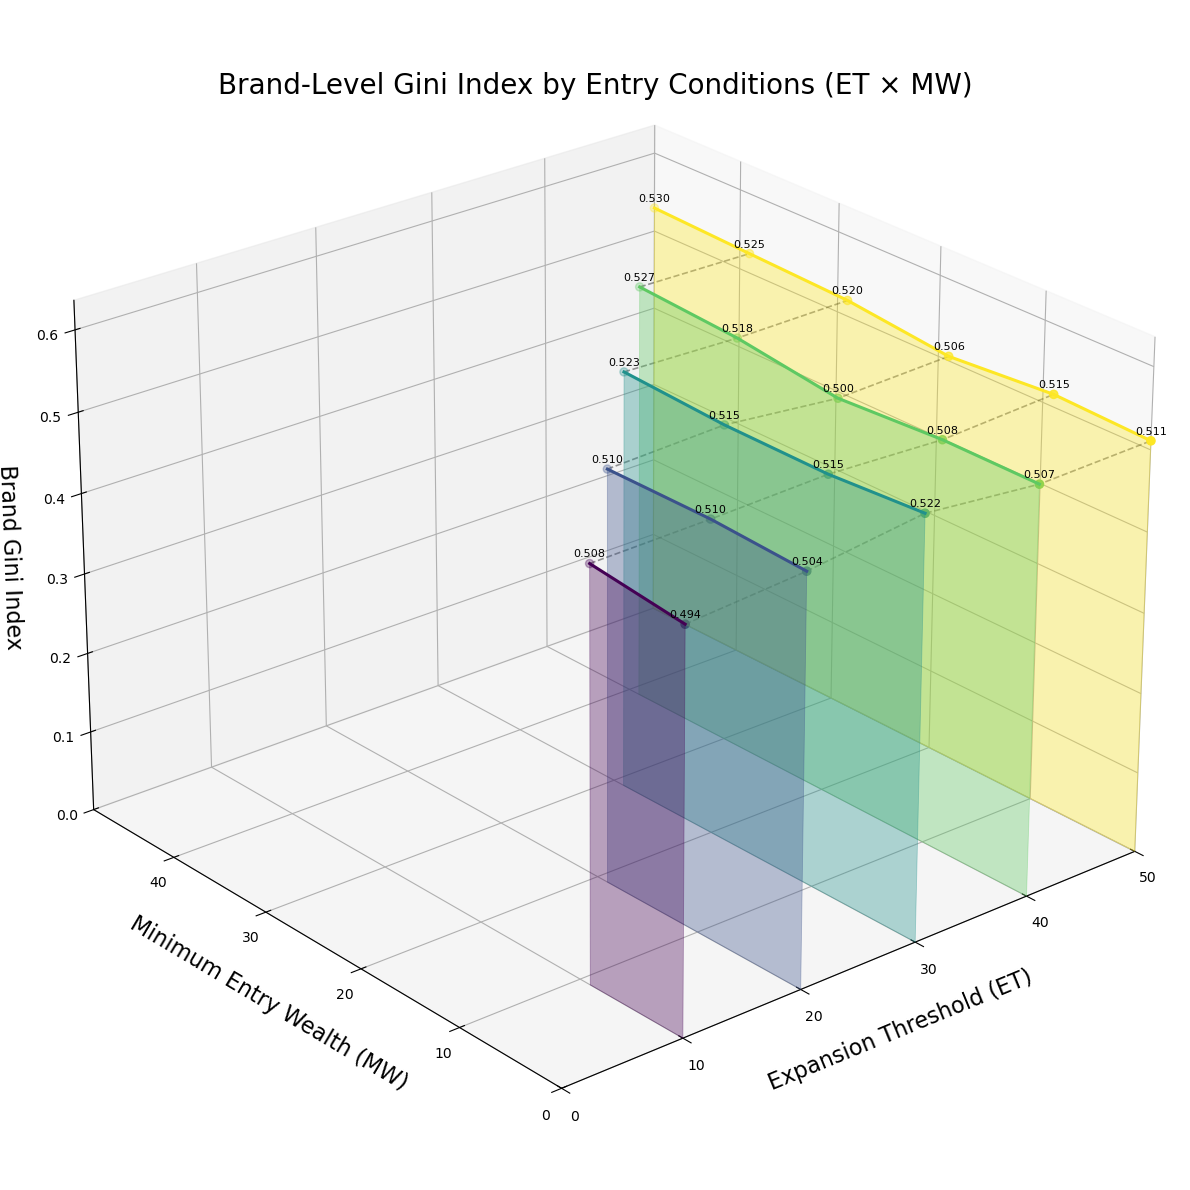

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(16, 12)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["brand-gini-index_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=8, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["brand-gini-index_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Expansion Threshold (ET)', labelpad=15, fontsize=16)
ax.set_ylabel('Minimum Entry Wealth (MW)', labelpad=15, fontsize=16)
ax.set_zlabel('Brand Gini Index', labelpad=10, fontsize=16)
ax.set_title('Brand-Level Gini Index by Entry Conditions (ET × MW)', pad=30, fontsize=20, y=0.97)

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(min_values.min(), min_values.max())
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["brand-gini-index_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.show()

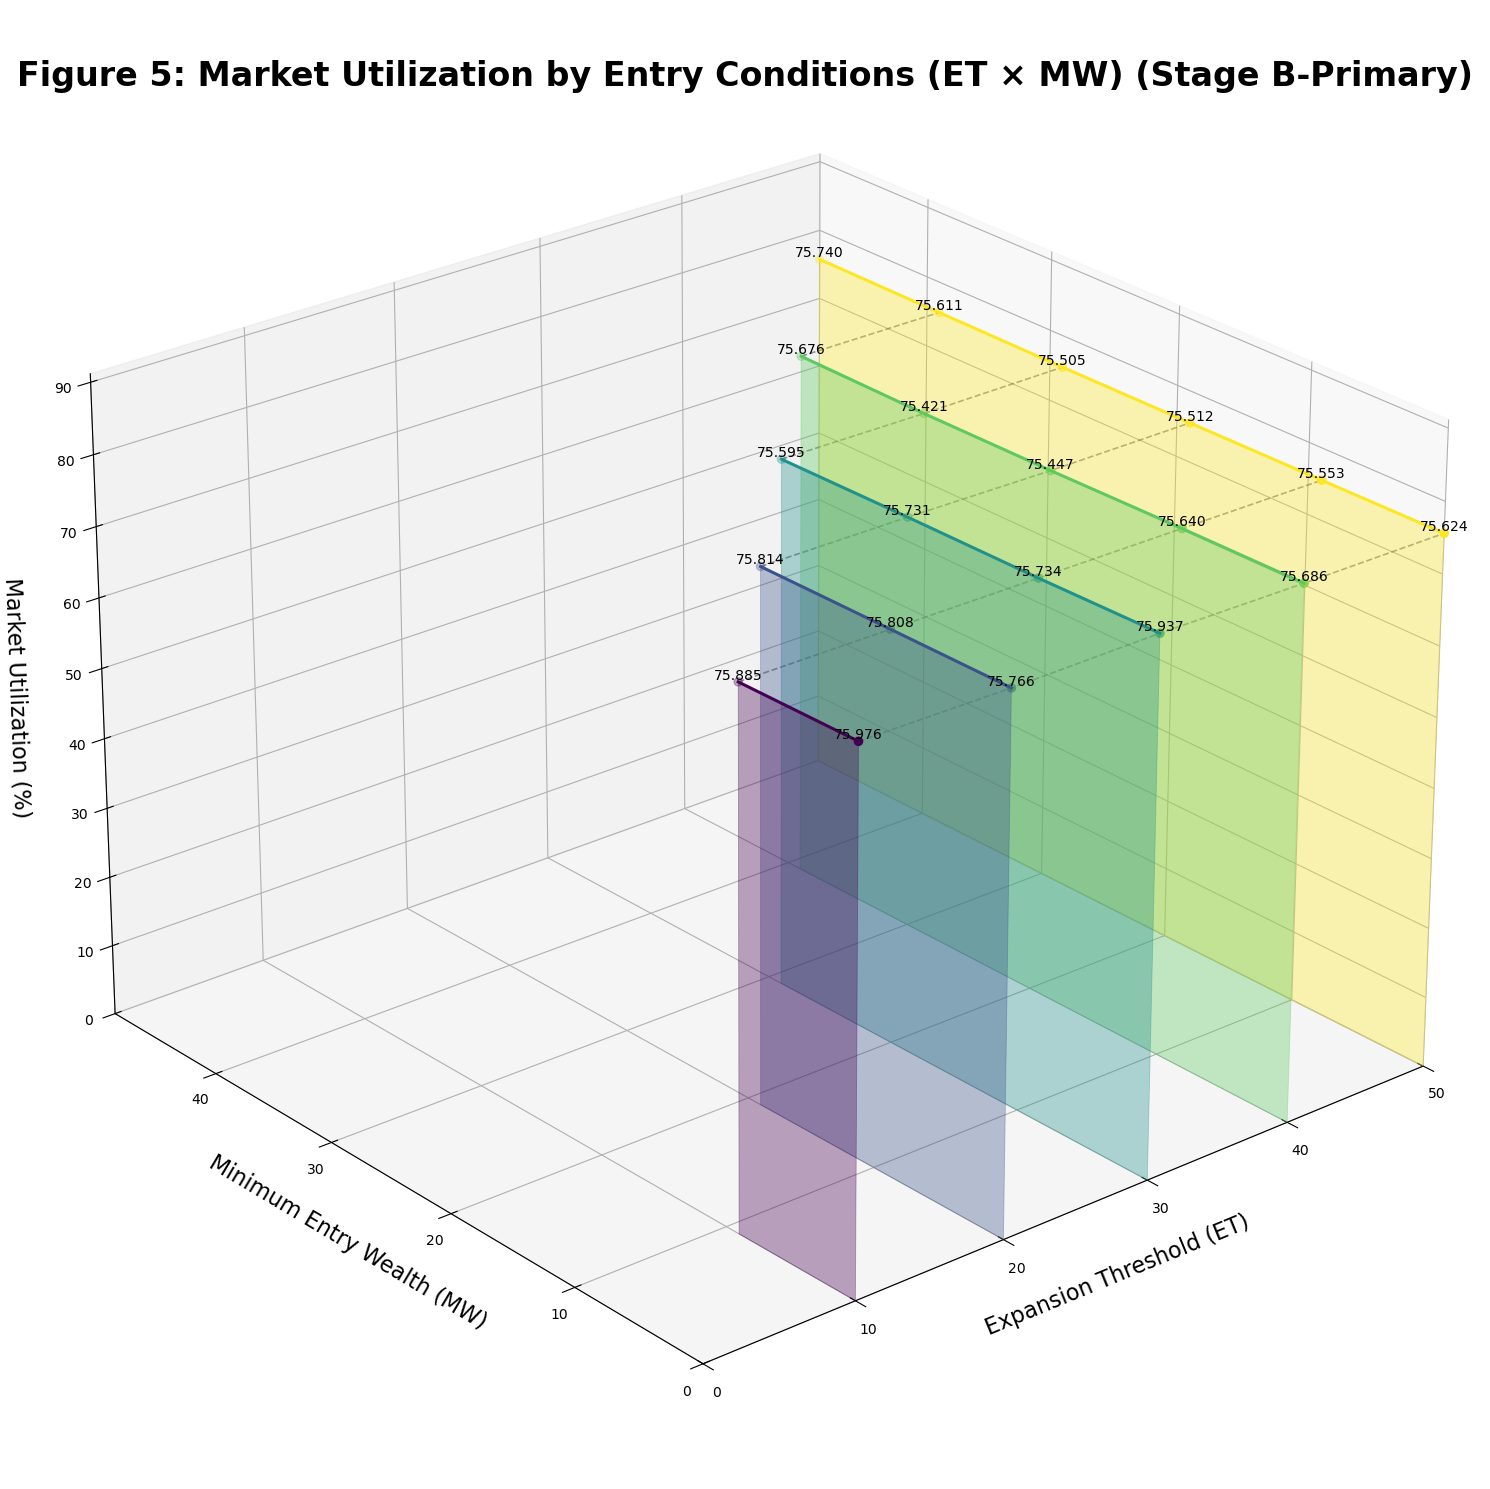

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()

    # Remove specific outlier/edge case: (max=1, min=0)
    df_plot = df_plot[~(
        (df_plot["maximum-sugar-endowment"] == 1) &
        (df_plot["minimum-sugar-endowment"] == 0)
    )]

    # Apply logical constraint: Max must be greater than Min
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]

    # Ensure data is sorted for consistent line drawing
    df_plot = df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])
    
    return df_plot

# Assuming experiment_B_1_1000Tick is already defined in your environment
df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(18, 15)) # Slightly larger to accommodate labels
ax = fig.add_subplot(111, projection='3d')

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOGIC
# ==========================================

# --- A. Waterfall Lines, Shading & Data Labels (Grouped by Max) ---
verts = []
for i, max_val in enumerate(max_values):
    group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")

    y_coords = group["minimum-sugar-endowment"].values
    z_coords = group["market-utilization_mean"].values
    x_coords = np.full(len(y_coords), max_val)

    # Main plot line
    ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=2.2, zorder=10)

    # Scatter points for markers
    ax.scatter(x_coords, y_coords, z_coords, color=colors[i], s=35, depthshade=True)

    # Add text labels for each point
    for x, y, z in zip(x_coords, y_coords, z_coords):
        # Format label to 3 decimal places
        label = f'{z:.3f}'
        # Add a small offset in Z direction to lift the text above the point
        ax.text(x, y, z + 0.005, label, 
                size=10, 
                zorder=20, 
                color='black', 
                ha='center', 
                va='bottom')

    # Prepare vertices for PolyCollection (Shading under the curves)
    path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
    path_z = np.concatenate([[0], z_coords, [0]])
    verts.append(list(zip(path_y, path_z)))

# Add shading areas
poly = PolyCollection(verts, facecolors=colors, alpha=0.35, edgecolors=colors, linewidths=0.6)
ax.add_collection3d(poly, zs=max_values, zdir='x')

# --- B. Transverse Connection Lines (Grouped by Min) ---
for min_val in min_values:
    group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")

    x_coords = group["maximum-sugar-endowment"].values
    y_coords = np.full(len(x_coords), min_val)
    z_coords = group["market-utilization_mean"].values

    # Dashed lines connecting the waterfalls
    ax.plot(x_coords, y_coords, z_coords, color='black', linewidth=1.2, linestyle='--', alpha=0.4)

# ==========================================
# 4. AXIS & VIEW STYLING
# ==========================================
ax.set_xlabel('Expansion Threshold (ET)', labelpad=15, fontsize=16)
ax.set_ylabel('Minimum Entry Wealth (MW)', labelpad=15, fontsize=16)
ax.set_zlabel('Market Utilization (%)', labelpad=15, fontsize=16, x = 0.9)
ax.set_title('Figure 5: Market Utilization by Entry Conditions (ET × MW) (Stage B-Primary)', pad=30, fontsize=24, fontweight='bold', y = 1 )

# Dynamic axis limits
ax.set_xlim(0, 50)
ax.set_ylim(min_values.min(), min_values.max())
# Extend Z-limit slightly more to ensure top labels aren't cut off
ax.set_zlim(0, df_plot["market-utilization_mean"].max() * 1.2)

# Set perspective
ax.view_init(elev=25, azim=-130)

plt.tight_layout()
plt.savefig('./figure/stage_B_1_1', dpi=300, bbox_inches='tight')
plt.show()

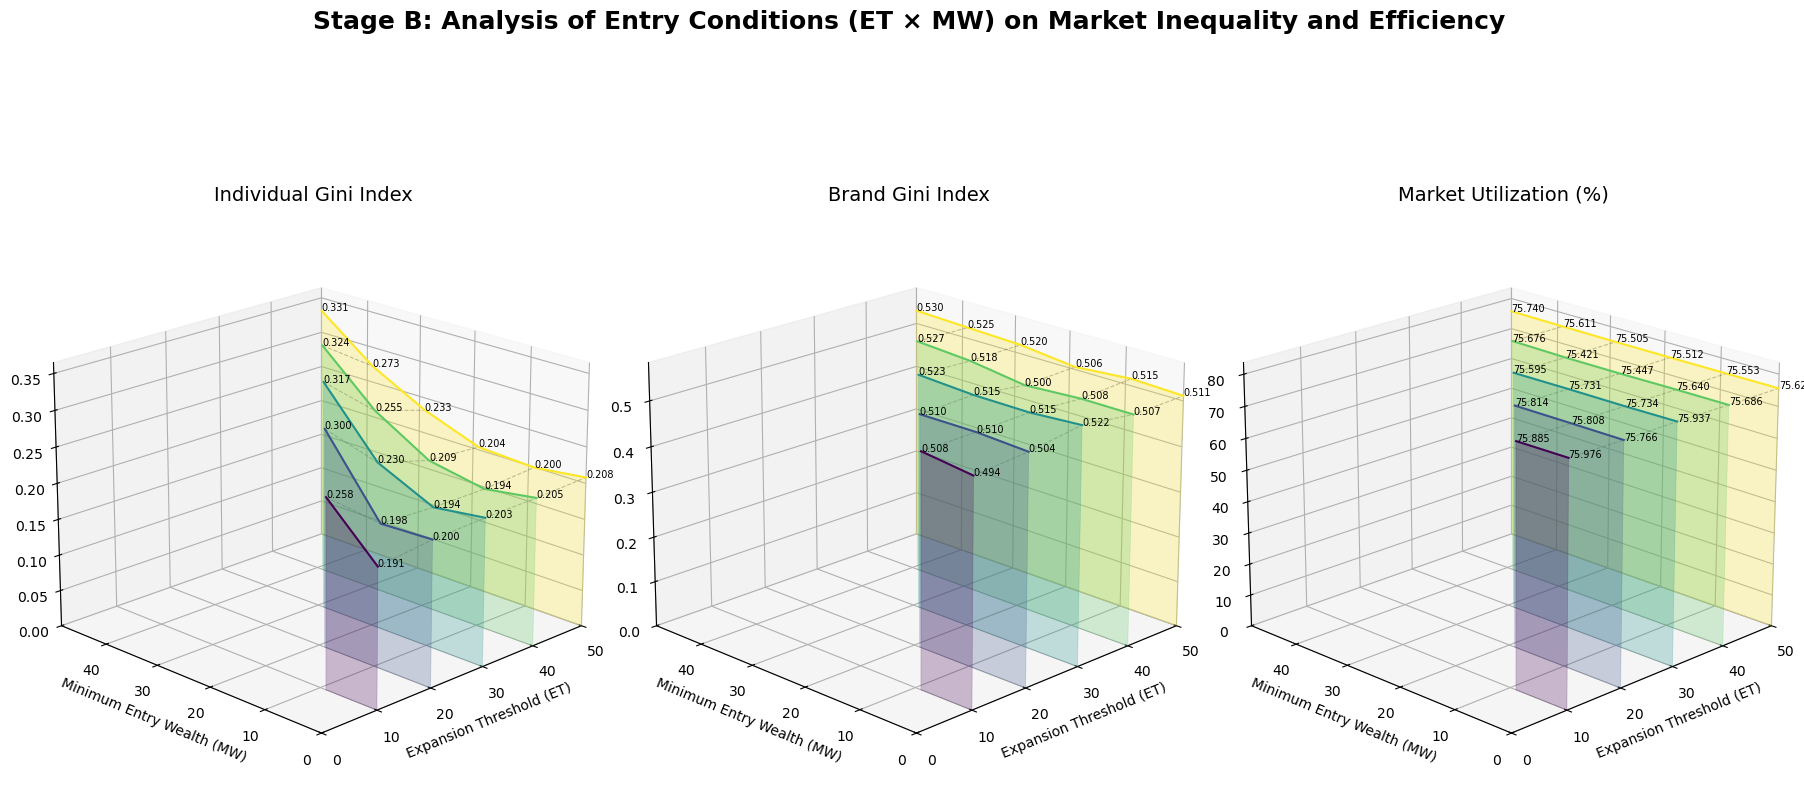

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()
    # Remove specific outlier/edge case
    df_plot = df_plot[~((df_plot["maximum-sugar-endowment"] == 1) & (df_plot["minimum-sugar-endowment"] == 0))]
    # Max > Min constraint
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]
    return df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])

df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
# Create a 1x3 layout for better comparison
fig = plt.figure(figsize=(18, 10)) 

metrics = [
    ("gini-index_mean", "Individual Gini Index"),
    ("brand-gini-index_mean", "Brand Gini Index"),
    ("market-utilization_mean", "Market Utilization (%)")
]

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(max_values)))

# ==========================================
# 3. CORE PLOTTING LOOP
# ==========================================
for idx, (column, title) in enumerate(metrics, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    
    verts = []
    # Plot Waterfall Lines & Shading
    for i, max_val in enumerate(max_values):
        group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")
        y_coords = group["minimum-sugar-endowment"].values
        z_coords = group[column].values
        x_coords = np.full(len(y_coords), max_val)

        # Main waterfall line
        ax.plot(x_coords, y_coords, z_coords, color=colors[i], linewidth=1.5, zorder=10)
        
        # --- NEW: ADD DATA LABELS FOR ALL POINTS ---
        for x, y, z in zip(x_coords, y_coords, z_coords):
            ax.text(x, y, z, f'{z:.3f}', fontsize=7, zorder=20)
        
        # Prepare shading
        path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
        path_z = np.concatenate([[0], z_coords, [0]])
        verts.append(list(zip(path_y, path_z)))

    # Add 3D Shading
    poly = PolyCollection(verts, facecolors=colors, alpha=0.25, edgecolors=colors, linewidths=0.5)
    ax.add_collection3d(poly, zs=max_values, zdir='x')

    # Transverse connections (Connecting across MW)
    for min_val in min_values:
        group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")
        x_c = group["maximum-sugar-endowment"].values
        y_c = np.full(len(x_c), min_val)
        z_c = group[column].values
        ax.plot(x_c, y_c, z_c, color='black', linewidth=0.8, linestyle='--', alpha=0.3)

    # Styling each subplot
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Expansion Threshold (ET)', fontsize=10)
    ax.set_ylabel('Minimum Entry Wealth (MW)', fontsize=10)
    #ax.set_zlabel('Value', fontsize=10)
    
    # View Control
    ax.view_init(elev=20, azim=-135)
    ax.set_xlim(0, 50)
    ax.set_ylim(min_values.min(), min_values.max())
    ax.set_zlim(0, df_plot[column].max() * 1.1)

# ==========================================
# 4. FINAL REFINEMENT
# ==========================================
fig.suptitle('Stage B: Analysis of Entry Conditions (ET × MW) on Market Inequality and Efficiency', 
             fontsize=18, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
#plt.savefig('./figure/stage_B_combined_3d.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26906/4102474382.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


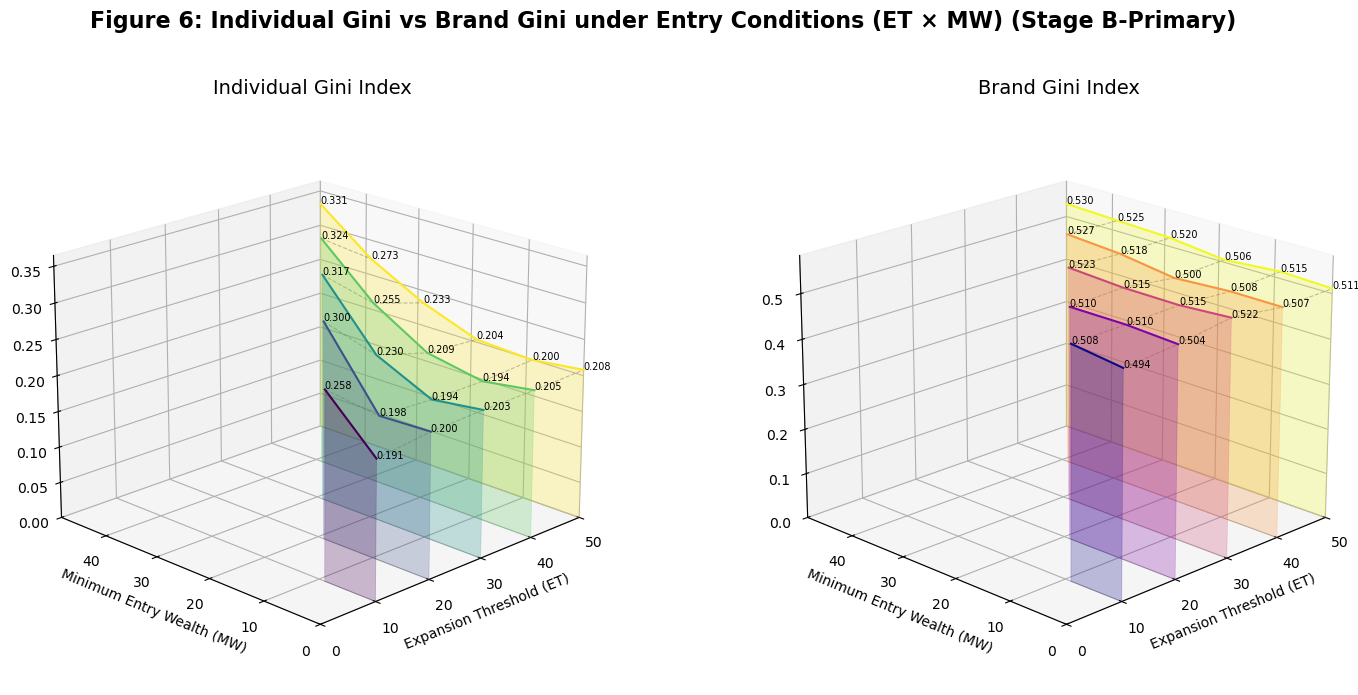

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
import matplotlib.gridspec as gridspec

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df):
    df_plot = df.copy()
    df_plot = df_plot[~((df_plot["maximum-sugar-endowment"] == 1) & (df_plot["minimum-sugar-endowment"] == 0))]
    df_plot = df_plot[df_plot["maximum-sugar-endowment"] > df_plot["minimum-sugar-endowment"]]
    return df_plot.sort_values(by=["maximum-sugar-endowment", "minimum-sugar-endowment"])

df_plot = preprocess_data(experiment_B_1_1000Tick)

# ==========================================
# 2. PLOT CONFIGURATION
# ==========================================
plt.style.use('default')
fig = plt.figure(figsize=(18, 7.5))

gs = gridspec.GridSpec(1, 2, wspace=0.15)

plot_configs = [
    ("gini-index_mean",       "Individual Gini Index", gs[0], plt.cm.viridis),
    ("brand-gini-index_mean", "Brand Gini Index",      gs[1], plt.cm.plasma),
]

max_values = np.sort(df_plot["maximum-sugar-endowment"].unique())
min_values = np.sort(df_plot["minimum-sugar-endowment"].unique())

# ==========================================
# 3. CORE PLOTTING LOOP
# ==========================================
for column, title, loc, cmap in plot_configs:
    ax = fig.add_subplot(loc, projection='3d')
    plot_colors = cmap(np.linspace(0, 1, len(max_values)))

    verts = []

    for i, max_val in enumerate(max_values):
        group = df_plot[df_plot["maximum-sugar-endowment"] == max_val].sort_values("minimum-sugar-endowment")
        y_coords = group["minimum-sugar-endowment"].values
        z_coords = group[column].values
        x_coords = np.full(len(y_coords), max_val)

        ax.plot(x_coords, y_coords, z_coords, color=plot_colors[i], linewidth=1.5, zorder=10)

        for x, y, z in zip(x_coords, y_coords, z_coords):
            ax.text(x, y, z, f'{z:.3f}', fontsize=7, zorder=20)

        path_y = np.concatenate([[y_coords[0]], y_coords, [y_coords[-1]]])
        path_z = np.concatenate([[0], z_coords, [0]])
        verts.append(list(zip(path_y, path_z)))

    poly = PolyCollection(verts, facecolors=plot_colors, alpha=0.25,
                          edgecolors=plot_colors, linewidths=0.5)
    ax.add_collection3d(poly, zs=max_values, zdir='x')

    for min_val in min_values:
        group = df_plot[df_plot["minimum-sugar-endowment"] == min_val].sort_values("maximum-sugar-endowment")
        x_c = group["maximum-sugar-endowment"].values
        y_c = np.full(len(x_c), min_val)
        z_c = group[column].values
        ax.plot(x_c, y_c, z_c, color='black', linewidth=0.8, linestyle='--', alpha=0.3)

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Expansion Threshold (ET)', fontsize=10)
    ax.set_ylabel('Minimum Entry Wealth (MW)', fontsize=10)
    ax.view_init(elev=20, azim=-135)
    ax.set_xlim(0, 50)
    ax.set_ylim(min_values.min(), min_values.max())
    ax.set_zlim(0, df_plot[column].max() * 1.1)

# ==========================================
# 4. FINAL REFINEMENT
# ==========================================
fig.suptitle('Figure 6: Individual Gini vs Brand Gini under Entry Conditions (ET × MW) (Stage B-Primary)',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('./figure/stage_B_1_2', dpi=500, bbox_inches='tight')
plt.show()

### Stage B — Secondary Experimen

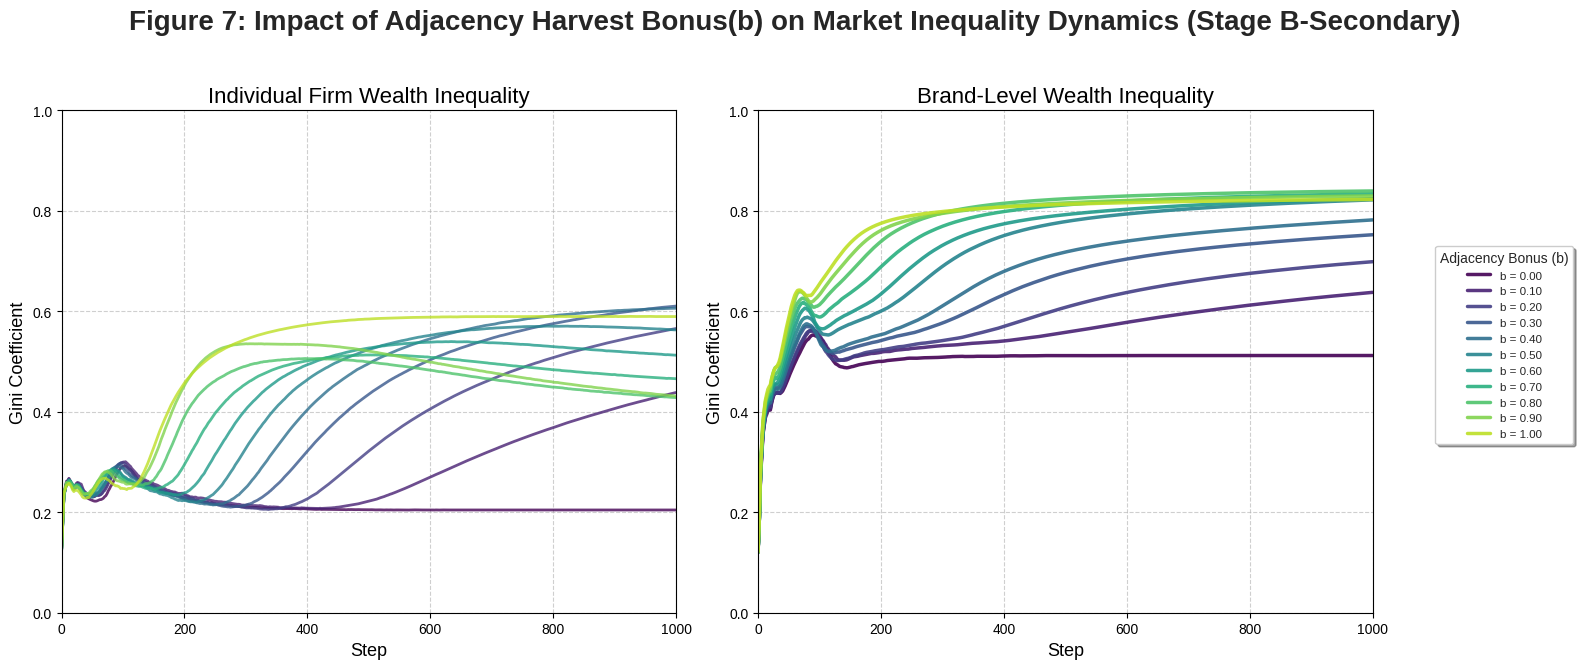

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

unique_gains = sorted(experiment_B_efficiency_gain_summary['efficiency-gain'].unique())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(unique_gains)))

for i, gain_val in enumerate(unique_gains):
    subset = experiment_B_efficiency_gain_summary[
        experiment_B_efficiency_gain_summary['efficiency-gain'] == gain_val
    ].sort_values('step')
    
    if subset.empty:
        continue
    x = subset['step'].values
    y_gini = subset['gini-index_mean'].values
    y_brand_gini = subset['brand-gini-index_mean'].values
    
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        
        spl_gini = make_interp_spline(x, y_gini, k=3)
        y_gini_smooth = spl_gini(x_smooth)
        
        spl_brand = make_interp_spline(x, y_brand_gini, k=3)
        y_brand_gini_smooth = spl_brand(x_smooth)
        
        ax1.plot(x_smooth, y_gini_smooth, color=colors[i], linewidth=2, alpha=0.8)
        ax2.plot(x_smooth, y_brand_gini_smooth, label=f'b = {gain_val:.2f}', 
                 color=colors[i], linewidth=2.5, alpha=0.9)
    else:
        ax1.plot(x, y_gini, color=colors[i], linewidth=2)
        ax2.plot(x, y_brand_gini, label=f'b = {gain_val:.2f}', color=colors[i], linewidth=2.5)

# 5. 左图
ax1.set_title('Individual Firm Wealth Inequality', fontsize=16)
ax1.set_xlabel('Step', fontsize=13)
ax1.set_ylabel('Gini Coefficient', fontsize=13)
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.6)

# 6. 右图
ax2.set_title('Brand-Level Wealth Inequality', fontsize=16)
ax2.set_xlabel('Step', fontsize=13)
ax2.set_ylabel('Gini Coefficient', fontsize=13)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1000)
ax2.grid(True, linestyle='--', alpha=0.6)

# 7. 图例
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title="Adjacency Bonus (b)", loc='center right',
           bbox_to_anchor=(0.99, 0.5), fontsize='small', frameon=True, shadow=True)

# 8. 总标题
fig.suptitle('Figure 7: Impact of Adjacency Harvest Bonus(b) on Market Inequality Dynamics (Stage B-Secondary)', 
             fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
plt.savefig('./figure/stage_B_2_1', dpi=300, bbox_inches='tight')
plt.show()

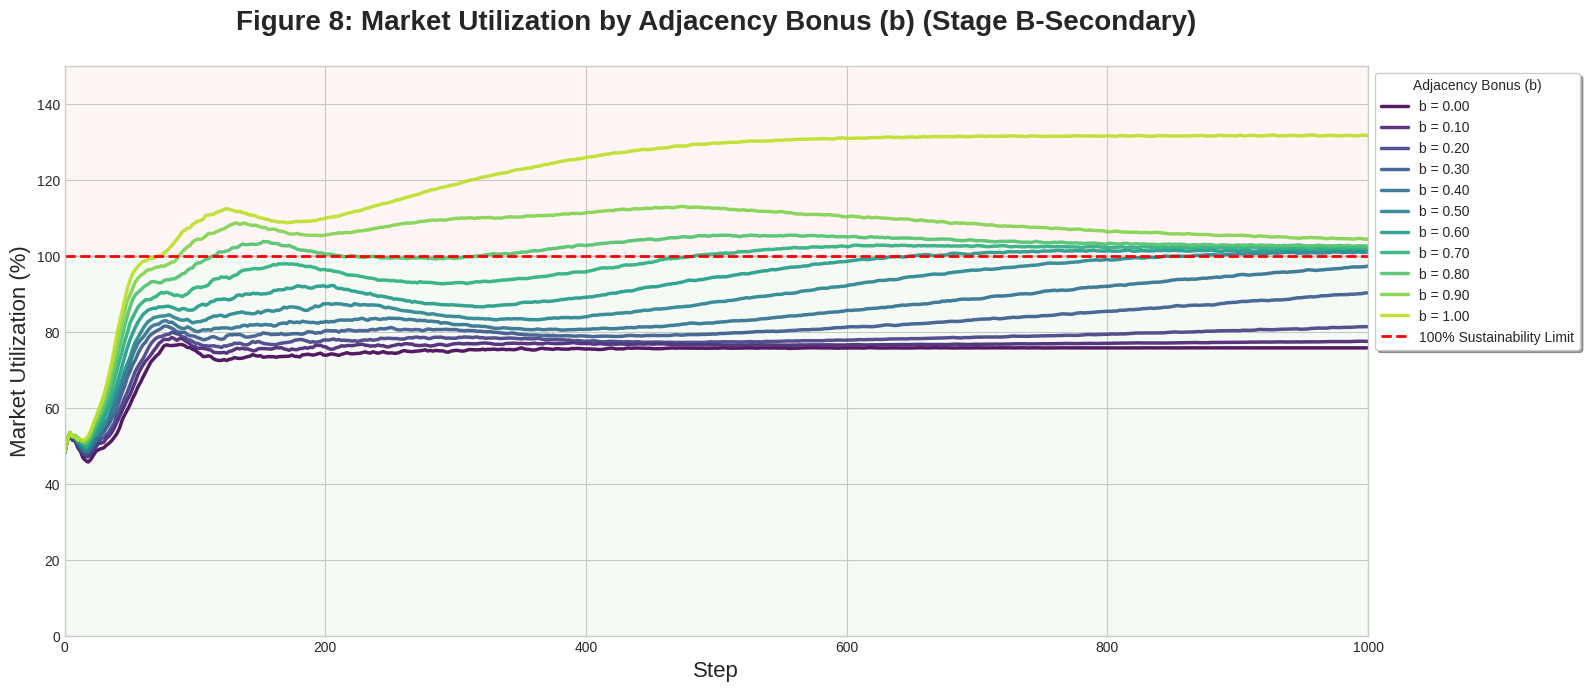

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure(figsize=(16, 7))
plt.style.use('seaborn-v0_8-whitegrid')

unique_gains = sorted(experiment_B_efficiency_gain_summary['efficiency-gain'].unique())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(unique_gains)))

for i, gain_val in enumerate(unique_gains):
    subset = experiment_B_efficiency_gain_summary[
        experiment_B_efficiency_gain_summary['efficiency-gain'] == gain_val
    ].sort_values('step')
    
    if subset.empty:
        continue
    x = subset['step'].values
    y_util = subset['market-utilization_mean'].values
    
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        spl = make_interp_spline(x, y_util, k=3)
        y_smooth = spl(x_smooth)
        plt.plot(x_smooth, y_smooth, label=f'b = {gain_val:.2f}', 
                 color=colors[i], linewidth=2.5, alpha=0.9)
    else:
        plt.plot(x, y_util, label=f'b = {gain_val:.2f}', 
                 color=colors[i], linewidth=2.5)

# 4. 100% 临界线
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, 
            label='100% Sustainability Limit')

# 5. 背景区域
plt.fill_between([0, 1000], 0, 100, color='green', alpha=0.04)
plt.fill_between([0, 1000], 100, 150, color='red', alpha=0.04)

# 6. 图表修饰
plt.title('Figure 8: Market Utilization by Adjacency Bonus (b) (Stage B-Secondary)', 
          fontsize=20, fontweight='bold', y = 1.05)
plt.xlabel('Step', fontsize=16)
plt.ylabel('Market Utilization (%)', fontsize=16)
plt.ylim(0, 150)
plt.xlim(0, 1000)

plt.legend(title="Adjacency Bonus (b)", loc='upper left', 
           bbox_to_anchor=(1, 1), frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('./figure/stage_B_2_2', dpi=300, bbox_inches='tight')
plt.show()